# 21_因果推断基础-因果图、混杂与识别假设

## Notebook 使用说明

建议先阅读《01. 从相关到因果》和《02. 随机试验与统计推断》。本篇需要 NumPy、pandas 和 Matplotlib；回归计算直接使用 NumPy，不需要安装额外的因果图软件包。

本篇数据：按参考资料 [1] 第 10、16 章及 [2] 第 5–7、11 章的因果结构另设的教学模拟。具体参数和数值不是原书的实证结果；碰撞变量案例将原书中的一个连续原因变量改为二元处理，练习中的 M 结构保留连续暴露，并在相应位置说明。

数据和图形都由本篇代码生成，不需要下载文件，也不依赖前两份 Notebook 的变量或 `notebook_support.py`。主案例采用总体视角，目标是 $E[Y(1)-Y(0)]$；重复模拟会重新生成研究对象，不是上一篇固定完整表后只重新分组。

代码输出和图形均保存在 Notebook 中。重新运行请使用 Restart Kernel and Run All Cells；下文解释对应默认参数，修改参数后以新的输出为准。

In [1]:
# 环境初始化：本篇不读取外部数据，单独放在一个文件夹中也可以运行。
import os
import sys
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib")
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.patches import Circle, FancyArrowPatch
from IPython.display import display

%matplotlib inline

_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [
    f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei",
                "SimHei", "Noto Sans CJK SC", "Noto Sans CJK JP"]
    if f in _available_fonts
] + ["DejaVu Sans"]
plt.rcParams.update({
    "font.sans-serif": CJK_FONTS,
    "axes.unicode_minus": False,
    "figure.dpi": 100,
    "figure.max_open_warning": 30,
})
pd.set_option("display.max_columns", 12)
pd.set_option("display.width", 120)

SEED_CONFOUNDING = 42
SEED_MEDIATION = 43
SEED_COLLIDER = 44
SEED_REPEAT = 2026
SEED_OVERLAP = 2027
SEED_DESCENDANT = 2028
SEED_M_BIAS = 2029
N_MAIN = 6000
N_REPEAT_SAMPLE = 600
N_REPEATS = 1000

print(f"Python {sys.version.split()[0]}")
print(f"NumPy {np.__version__} | pandas {pd.__version__} | Matplotlib {plt.matplotlib.__version__}")

Python 3.13.5
NumPy 2.3.5 | pandas 2.2.3 | Matplotlib 3.10.8


上一篇依靠随机分组，让均值差有了因果解释。但观察性研究里的处理往往不是抽签决定的，还能照样比较吗？

常见做法是在回归里多放几个变量，希望把两组调整得更可比。这里又有一个问题：应该放哪些变量？处理前的基础情况、处理后的变化、决定样本是否被留下的指标，它们都能进入回归，却不一定都适合用来调整。

下面先用因果图区分这些关系，再做三个完整模拟。回归工具始终相同，只改变变量之间的生成关系，看看“多调整一个变量”分别带来了什么。

## 理论基础

### 1. 因果图画的是什么？

因果图用节点表示变量，用有向箭头表示假定的直接因果关系。例如 $X	o T$ 表示在这个模型中，改变 $X$ 可以影响 $T$ 的生成，而不是仅仅说两列数据相关。

本篇使用有向无环图（Directed Acyclic Graph，DAG）。“无环”表示沿着箭头一直走，不能再回到出发点。直接指向某个节点的是它的父节点，沿箭头向后能到达的是它的后代。[2，第 7.3 节]

图可以和结构方程一起读。例如：

$$
X=f_X(\varepsilon_X),\qquad
T=f_T(X,\varepsilon_T),\qquad
Y=f_Y(T,X,\varepsilon_Y).
$$

先生成 $X$，再用 $X$ 生成 $T$，最后用 $T,X$ 生成 $Y$。相应的箭头就是 $X\to T$、$X\to Y$ 和 $T\to Y$。本篇各例中的外生随机项相互独立；如果存在未表示出来的共同原因，这个图就不完整。[1，第 16.1 节；2，第 7.2–7.3 节]

结构方程还要求：干预一个变量时，其余方程的生成机制保持不变。这样才有办法沿方程计算干预后的结局。仅仅把一次回归拟合写成方程，并没有自动得到这个性质。[2，第 7.2 节]

所以，画图不是让软件从相关系数里猜箭头。这里先明确假定的生成过程，再研究这些假定允许我们做什么比较。

### 2. 三种容易混淆的结构

先看一条路径的中间节点。路径可以顺着箭头，也可以逆着箭头走；箭头方向仍然保留，不因我们从哪端阅读而改变。[2，第 7.3 节]

| 结构 | 典型路径 | 不调整中间节点时 | 调整中间节点后 |
|---|---|---|---|
| 共同原因，也叫叉形结构 | $T\leftarrow X\to Y$ | 这条非因果路径开放 | 路径被阻断 |
| 中介，也叫链式结构 | $T\to M\to Y$ | 这条因果路径开放 | 经 $M$ 传递的路径被阻断 |
| 碰撞结构 | $T\to C\leftarrow Y$ | 这条路径本来被阻断 | 碰撞点处的阻断被打开 |

第一行中的 $X$ 同时影响处理和结局，是需要考虑的混杂变量。第二行的 $M$ 则是处理影响结局的一部分机制；研究总效应时，这部分通常也应算进去。第三行的 $C$ 同时接收两边的箭头，是这条路径上的碰撞变量（collider）。[1，第 16.1、16.3 节；2，第 6.2–6.3 节]

这里的“调整”是统计上的条件化，可以通过分层、回归等方式实现；只保留某个指标满足条件的人，也是一种条件化。它不等于现实中对这个变量施加干预。[2，第 6.3、11.3 节]

碰撞变量的角色是相对于一条具体路径说的。同一个节点在另一条路径上未必还是碰撞点，不能只看变量名称就把它永久归为“应该调”或“不应该调”。

### 3. d-分离与后门调整

判断一条路径是否开放，需要同时检查两件事：路径上的非碰撞中间节点没有被条件化；路径上的每个碰撞节点本身或它的某个后代被条件化。任一条件不满足，这条路径就被阻断。特别是，调整碰撞变量的后代也可能打开原来的阻断点；如果路径上另有阻断点，整条路径仍然不开放。[2，定义 7.3.8–7.3.10]

如果一个集合 $S$ 阻断两个节点之间的所有路径，就称它们被 $S$ d-分离。在书中的因果 DAG／结构方程假设下，d-分离蕴含相应的条件独立；反过来，某次样本相关接近零不能证明图上不存在路径。[2，定理 7.3.2]

估计 $T$ 对 $Y$ 的总效应时，我们不是要阻断所有路径，而是要保留 $T\to Y$ 这样的因果通路，阻断造成混杂的后门路径。下面统一从 $T$ 向 $Y$ 阅读：第一条边的箭头指向 $T$ 的路径，称为相对于处理 $T$ 的后门路径。例如 $T\leftarrow X\to Y$。

常用的后门准则要求调整集合 $S$ 满足：其中没有 $T$ 的后代，而且它阻断所有后门路径。这是在给定 DAG 下寻找合适调整集合的一条充分准则，不是所有可行识别方法的总清单。[2，定理 7.4.2及其后讨论]

注意区别：计算 $\operatorname{ATE}$ 时希望保留处理的作用，并不要求调整后 $T$ 与观察结局 $Y$ 独立。真正需要考虑的是，调整后 $T$ 与潜在结局 $Y(t)$ 的关系。

### 4. 从“图上可以调整”到识别假设

本篇前三个案例都用二元处理，目标为：

$$
\operatorname{ATE}=E[Y(1)-Y(0)].
$$

采用协变量调整时，下面几项是常用的充分条件。[1，第 2.2、10.3 节；2，第 5.2 节]

第一，处理定义清楚，没有个体间干扰，且观察结局与实际处理对应：

$$
Y=TY(1)+(1-T)Y(0).
$$

第二，给定合适的处理前变量 $X$，处理与各个潜在结局条件独立：

$$
Y(t)\perp\!\!\!\perp T\mid X,\qquad t=0,1.
$$

这是条件可忽略性（conditional ignorability），也称无混杂假设。它不是说“$X$ 相同的人结果完全一样”，而是说他们接受哪种处理，不再提供关于潜在结局的额外信息。Ding 还区分了分别独立、联合独立和较弱的条件均值假设；这里使用分别条件独立的写法，不把它声称为识别 ATE 的最弱条件。[1，第 10.3.1 节]

第三，目标人群中几乎处处都有两种处理的可能：

$$
0<e(X)<1,\qquad e(X)=P(T=1\mid X).
$$

这就是重叠或正值性（overlap / positivity）。如果某类人全部接受处理，我们就没有同类对照，不能直接做层内比较。图中画了哪些箭头，并没有同时告诉我们这些概率是多少。[2，假设 5.2.2；第 6.2 节的备注 6.2.1]

其中无混杂假设涉及未观察到的反事实，不能单靠当前数据证明。画出一个方便的图，也不等于验证了它；需要用时间顺序、研究设计和已有知识来说明图中哪些关系可信。[1，第 10.3.2、16.2 节]

### 5. 调整公式怎样得到？

在上述条件下，对 $t=0,1$ 分别有：

$$
\begin{aligned}
E[Y(t)]
&=E_X\{E[Y(t)\mid X]\}\\
&=E_X\{E[Y(t)\mid T=t,X]\}\\
&=E_X\{E[Y\mid T=t,X]\}.
\end{aligned}
$$

第一步是全期望公式，第二步使用条件可忽略性，第三步使用观察结局与潜在结局的对应关系。重叠条件保证每类 $X$ 下都有机会观察 $T=t$，从而能用观察数据中的条件分布表达最后一项。[1，定理 10.1；2，定理 5.2.1]

两式相减，得到：

$$
\operatorname{ATE}
=E_X\{E[Y\mid T=1,X]-E[Y\mid T=0,X]\}.
$$

若 $X$ 只有有限个取值，就写成：

$$
\operatorname{ATE}
=\sum_x\{E[Y\mid T=1,X=x]-E[Y\mid T=0,X=x]\}P(X=x).
$$

两种处理使用同一套目标人群权重 $P(X=x)$。第一篇肾结石案例里“统一病例构成”的计算，现在有了明确的假设依据；但原来的汇总数据本身仍不足以证明无混杂。

识别解决的是：在假设成立时，能否把因果目标写成观察数据分布的函数。估计才是用有限样本计算这个函数，统计推断再描述估计的随机误差。后面故意选用简单线性生成模型，让回归计算不成为主要障碍，重点检查变量调得对不对。

## 完整案例一：调整混杂变量

假设 $T$ 表示是否参加某项辅导，$X$ 表示处理前的基础类别，$Y$ 是后续成绩指标。这里只用这个背景帮助理解，所有数值均为教学设定，结局使用任意单位。

我们假设基础类别既影响参加辅导的概率，也影响后续成绩；辅导本身另有作用。图对应 [1] 第 16.1 节和 [2] 第 5.2 节的共同原因结构。

### 1. 先画关系，再生成数据

下面的画图函数只负责按给定节点和箭头画图，不从数据推断因果关系，也不自动寻找调整集。

In [2]:
def draw_dag(positions, edges, labels, title, latent=()):
    """绘制本篇的小型 DAG；虚线圆圈表示未观测变量。"""
    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    radius = 0.30
    for parent, child in edges:
        start = np.asarray(positions[parent], dtype=float)
        end = np.asarray(positions[child], dtype=float)
        direction = (end - start) / np.linalg.norm(end - start)
        arrow = FancyArrowPatch(
            start + (radius + 0.04) * direction,
            end - (radius + 0.04) * direction,
            arrowstyle="-|>", mutation_scale=17, linewidth=1.5,
            shrinkA=0, shrinkB=0,
        )
        ax.add_patch(arrow)
    for node, (x, y) in positions.items():
        ax.add_patch(Circle(
            (x, y), radius, fill=False, linewidth=1.5,
            linestyle="--" if node in latent else "-",
        ))
        ax.text(x, y, node, ha="center", va="center", fontsize=14)
        label_y = y + 0.54 if node in latent else y - 0.53
        ax.text(x, label_y, labels.get(node, ""),
                ha="center", va="center", fontsize=10)
    xy = np.asarray(list(positions.values()))
    ax.set_xlim(xy[:, 0].min() - 0.9, xy[:, 0].max() + 0.9)
    top_margin = 0.90 if latent else 0.65
    ax.set_ylim(xy[:, 1].min() - 0.9, xy[:, 1].max() + top_margin)
    ax.set_aspect("equal")
    ax.set_title(title, pad=15)
    ax.axis("off")
    fig.tight_layout()
    plt.show()
    plt.close(fig)

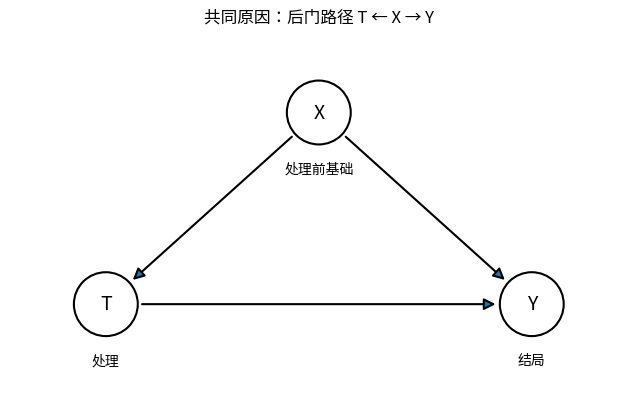

In [3]:
draw_dag(
    positions={"X": (2, 1.8), "T": (0, 0), "Y": (4, 0)},
    edges=[("X", "T"), ("X", "Y"), ("T", "Y")],
    labels={"X": "处理前基础", "T": "处理", "Y": "结局"},
    title="共同原因：后门路径 T ← X → Y",
)

这里有一条因果路径 $T\to Y$，还有一条后门路径 $T\leftarrow X\to Y$。调整 $X$ 是为了阻断第二条，而不是把 $T$ 对 $Y$ 的作用一起去掉。

具体生成规则另设为：

$$
\begin{aligned}
X&\sim\operatorname{Bernoulli}(0.5),\\
e(X)&=0.2+0.6X,\\
T\mid X&\sim\operatorname{Bernoulli}(e(X)),\\
Y(t)&=10+2t+3X+\varepsilon_Y,\qquad \varepsilon_Y\sim N(0,1).
\end{aligned}
$$

生成处理的随机数与结局误差独立。给定 $X$ 后，两者不再共享其他随机来源，所以本模型满足条件可忽略性。两类人的处理概率分别为 0.2、0.8，也满足重叠。

每个人都有 $Y(1)-Y(0)=2$，因此总体 ATE 和任何一张完整表的真实平均效应都恰好为 2。下面把观察数据与潜在结局分开保存。

In [4]:
def generate_confounding(n: int, rng: np.random.Generator):
    """按上面的共同原因模型生成观察数据及模拟真值。"""
    x = rng.binomial(1, 0.5, size=n)
    propensity = 0.2 + 0.6 * x
    t = rng.binomial(1, propensity)
    noise_y = rng.normal(size=n)
    y0 = 10 + 3 * x + noise_y
    y1 = y0 + 2
    y = np.where(t == 1, y1, y0)
    observed = pd.DataFrame({"X": x, "T": t, "Y": y})
    truth = pd.DataFrame({"Y0": y0, "Y1": y1})
    return observed, truth

observed_conf, truth_conf = generate_confounding(
    N_MAIN, np.random.default_rng(SEED_CONFOUNDING)
)
display(observed_conf.head().round(3))
print(f"模拟真实平均效应：{(truth_conf['Y1'] - truth_conf['Y0']).mean():.4f}")

,X,T,Y
0,1,1,15.279
1,0,0,8.788
2,1,1,14.595
3,1,1,14.362
4,0,0,9.014


模拟真实平均效应：2.0000


### 2. 先不调整，再分层查看

先只看处理组与对照组。除了结局均值，也把两组中 $X=1$ 的比例列出来，看看直接比较的究竟是哪两类人。

In [5]:
group_summary = observed_conf.groupby("T").agg(
    人数=("Y", "size"),
    基础类别1比例=("X", "mean"),
    结局均值=("Y", "mean"),
)
display(group_summary.round(4))
raw_conf = float(group_summary.loc[1, "结局均值"] - group_summary.loc[0, "结局均值"])
print(f"整体观察均值差：{raw_conf:.4f}")

stratum_summary = observed_conf.groupby(["X", "T"]).agg(
    人数=("Y", "size"), 结局均值=("Y", "mean")
)
display(stratum_summary.round(4))

,人数,基础类别1比例,结局均值
T,,,
0,2970,0.1845,10.6016
1,3030,0.7937,14.3705


整体观察均值差：3.7689


人数     结局均值
X T               
0 0  2422  10.0502
  1   625  11.9448
1 0   548  13.0384
  1  2405  15.0009

整体差值应接近 3.8，而不是真实效应 2。这个数可以直接从设定算出来：$P(T=1)=0.5$，所以由贝叶斯公式，$P(X=1\mid T=1)=0.8$，$P(X=1\mid T=0)=0.2$。因此：

$$
E[Y\mid T=1]-E[Y\mid T=0]
=2+3(0.8-0.2)=3.8.
$$

多出来的 1.8 来自两组基础构成的差别。在每一类 $X$ 内，处理组与对照组的均值差则应接近 2。以下图表都由刚才生成的观察数据计算，不直接画设定的理论数值。

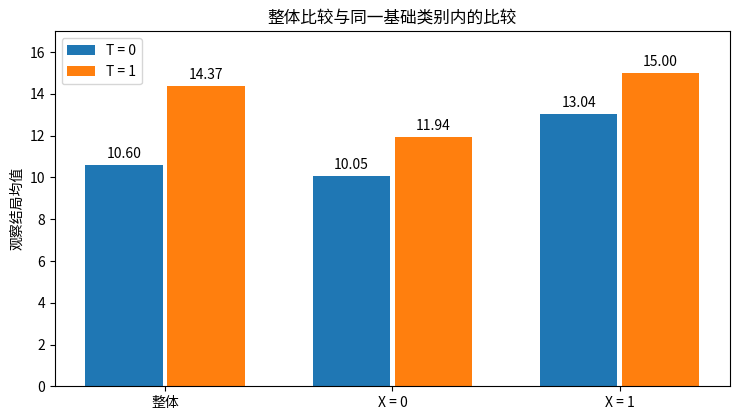

In [6]:
means_conf = stratum_summary["结局均值"].unstack("T").reindex(columns=[0, 1])
plot_means = pd.DataFrame(
    [group_summary["结局均值"].to_numpy(),
     means_conf.loc[0].to_numpy(), means_conf.loc[1].to_numpy()],
    index=["整体", "X = 0", "X = 1"], columns=[0, 1],
)
fig, ax = plt.subplots(figsize=(7.5, 4.3))
positions = np.arange(len(plot_means))
for t, offset in [(0, -0.18), (1, 0.18)]:
    bars = ax.bar(positions + offset, plot_means[t], width=0.34, label=f"T = {t}")
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=10)
ax.set_xticks(positions, plot_means.index)
ax.set_ylabel("观察结局均值")
ax.set_ylim(0, float(plot_means.to_numpy().max()) + 2)
ax.set_title("整体比较与同一基础类别内的比较")
ax.legend()
fig.tight_layout()
plt.show()
plt.close(fig)

### 3. 两种处理使用同一套人群权重

现在用样本中两类 $X$ 的比例，对层内差值加权。这一步只读取 `observed_conf`，不使用反事实列。[1，第 10.4.1 节]

随后再拿完整表核对。“让所有人都接受处理”和“筛选已经接受处理的人”是两种不同操作：前者保留原来的人群构成，后者在本例中筛出了更多 $X=1$ 的人。

In [7]:
weights_conf = observed_conf["X"].value_counts(normalize=True).sort_index()
within_diff = means_conf[1] - means_conf[0]
standardized_conf = float((within_diff * weights_conf).sum())
display(pd.DataFrame({
    "目标人群权重": weights_conf,
    "层内观察差值": within_diff,
    "加权贡献": weights_conf * within_diff,
}).round(4))

# 只在模拟核对时读取潜在结局：保留同一批人，分别令 T=0 和 T=1。
comparison_conf = pd.DataFrame({
    "比较方式": ["直接比较实际两组", "按共同 X 分布标准化", "模拟完整表：所有人处理与不处理"],
    "结局差": [raw_conf, standardized_conf,
               float((truth_conf["Y1"] - truth_conf["Y0"]).mean())],
})
display(comparison_conf.round(4))

,目标人群权重,层内观察差值,加权贡献
X,,,
0,0.5078,1.8945,0.9621
1,0.4922,1.9624,0.9658


,比较方式,结局差
0,直接比较实际两组,3.7689
1,按共同 X 分布标准化,1.9280
2,模拟完整表：所有人处理与不处理,2.0000


默认样本的整体差值约为 3.7689，标准化后约为 1.9280，接近真实效应 2，但没有恰好等于 2。这份样本的层内均值仍有抽样误差，不能把一次结果与真值的差别都归因于混杂。

调整不是靠“把相关性调小”得到的，而是先有关于 $X$ 的识别假设，再用同一人群构成汇总两种处理下的结果。

### 4. 用回归再算一次

因为本例的条件结局均值是 $10+2T+3X$，线性回归恰好与设定相符。比较 `Y ~ T` 和 `Y ~ T + X` 中的 $T$ 系数，应该分别接近 3.8 和 2。

下面把最小二乘计算封装起来。函数只做线性拟合，没有任何“自动消除混杂”的步骤。输出依次是截距和各个自变量的系数；若设计矩阵不满秩，就停止并报错，而不是给出看似唯一的系数。[1，附录 B.2；2，第 5.2、6.1 节]

In [8]:
def fit_ols(y, *regressors):
    """返回 [截距, 第1个自变量系数, ...]；不赋予系数因果含义。"""
    y = np.asarray(y, dtype=float)
    xs = [np.asarray(x, dtype=float) for x in regressors]
    if y.ndim != 1 or not xs or any(x.shape != y.shape for x in xs):
        raise ValueError("结局与每个自变量必须是一维、等长数组，且至少有一个自变量。")
    design = np.column_stack([np.ones(y.size), *xs])
    if y.size <= design.shape[1]:
        raise ValueError("样本数必须大于需要估计的系数个数。")
    if not np.isfinite(y).all() or not np.isfinite(design).all():
        raise ValueError("输入不能包含 NaN 或无穷值。")
    beta, _, rank, _ = np.linalg.lstsq(design, y, rcond=None)
    if rank < design.shape[1]:
        raise ValueError("设计矩阵不满秩：不能单独确定每个回归系数。")
    return beta

coef_conf_raw = fit_ols(observed_conf["Y"], observed_conf["T"])
coef_conf_adjusted = fit_ols(observed_conf["Y"], observed_conf["T"], observed_conf["X"])
np.testing.assert_allclose(coef_conf_raw[1], raw_conf)
display(pd.DataFrame({
    "模型": ["Y ~ T", "Y ~ T + X"],
    "T 的回归系数": [coef_conf_raw[1], coef_conf_adjusted[1]],
    "本模型的总体回归系数": [3.8, 2.0],
    "目标总效应": [2.0, 2.0],
}).round(4))

,模型,T 的回归系数,本模型的总体回归系数,目标总效应
0,Y ~ T,3.7689,3.8,2.0
1,Y ~ T + X,1.9267,2.0,2.0


这次调整 $X$ 有效，因为它同时满足两个条件：图中选对了变量，回归形式也适合这个数据生成模型。换成非线性或有交互的结局关系，仅仅把同名变量放进线性回归，不一定就能正确实现调整公式。下一篇会专门讨论回归调整与标准化。

## 完整案例二：把中介变量也调进去

现在换一个模型。$T$ 随机分配，$M$ 表示处理后的练习投入指标，$Y$ 是后续成绩指标。处理既直接影响成绩，也通过 $M$ 影响成绩。

### 1. 明确我们要的是总效应

图中没有指向 $T$ 的箭头，即没有本例需要阻断的后门路径。$M$ 位于 $T\to M\to Y$ 上，是中介，不是处理前的混杂因素。[2，第 6.2、11.3 节]

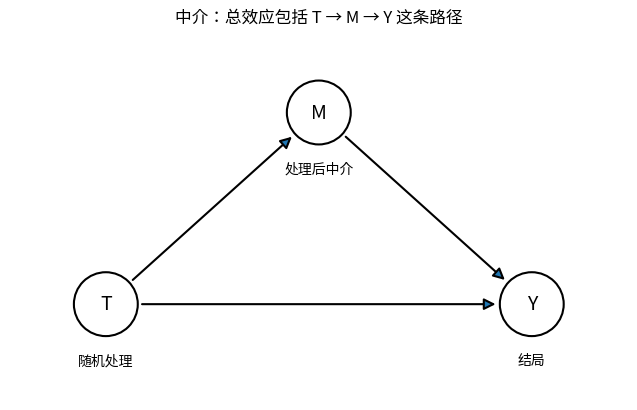

In [9]:
draw_dag(
    positions={"M": (2, 1.8), "T": (0, 0), "Y": (4, 0)},
    edges=[("T", "M"), ("M", "Y"), ("T", "Y")],
    labels={"M": "处理后中介", "T": "随机处理", "Y": "结局"},
    title="中介：总效应包括 T → M → Y 这条路径",
)

按这个结构，另设：

$$
\begin{aligned}
T&\sim\operatorname{Bernoulli}(0.5),\\
M(t)&=1.5t+\varepsilon_M,\\
Y(t,m)&=10+t+2m+\varepsilon_Y,
\end{aligned}
$$

其中 $T,\varepsilon_M,\varepsilon_Y$ 相互独立，两个误差均服从 $N(0,1)$。

让 $T$ 从 0 变成 1 时，中介也会随之变化。所以自然随处理变化的结局是 $Y(t)=Y(t,M(t))$，代入得到：

$$
Y(t)=10+4t+2\varepsilon_M+\varepsilon_Y.
$$

总效应是 $4$，其中直接路径贡献 $1$，经中介路径贡献 $1.5\times2=3$。如果另问“把 $M$ 固定在同一个值 $m$，再改变 $T$”，则比较的是：

$$
Y(1,m)-Y(0,m)=1.
$$

它是这个模型中的受控直接效应，不是总效应。[2，第 6.2 节的线性路径分解；第 7.2 节的嵌套结局；第 11.3 节的受控直接效应]

In [10]:
def generate_mediation(n: int, rng: np.random.Generator):
    """生成有直接路径和中介路径的随机处理模型。"""
    t = rng.binomial(1, 0.5, size=n)
    noise_m = rng.normal(size=n)
    noise_y = rng.normal(size=n)
    m0 = noise_m
    m1 = 1.5 + noise_m
    m = np.where(t == 1, m1, m0)
    y0 = 10 + 2 * m0 + noise_y
    y1 = 10 + 1 + 2 * m1 + noise_y
    y = np.where(t == 1, y1, y0)
    observed = pd.DataFrame({"T": t, "M": m, "Y": y})
    truth = pd.DataFrame({"M0": m0, "M1": m1, "Y0": y0, "Y1": y1})
    return observed, truth

observed_med, truth_med = generate_mediation(
    N_MAIN, np.random.default_rng(SEED_MEDIATION)
)
display(observed_med.head().round(3))
print(f"模拟真实总效应：{(truth_med['Y1'] - truth_med['Y0']).mean():.4f}")

,T,M,Y
0,1,0.551,12.189
1,0,0.086,8.715
2,0,-2.496,6.127
3,1,3.673,20.786
4,1,2.255,16.129


模拟真实总效应：4.0000


### 2. 比较不调整与调整 M

沿用刚才的回归函数。`Y ~ T` 允许中介随处理自然变化，`Y ~ T + M` 则比较同一 $M$ 下的 $T$ 差异。在当前独立误差、线性可加的设定下，两者分别对应总效应与直接效应。

In [11]:
coef_med_raw = fit_ols(observed_med["Y"], observed_med["T"])
coef_med_adjusted = fit_ols(observed_med["Y"], observed_med["T"], observed_med["M"])
coef_t_to_m = fit_ols(observed_med["M"], observed_med["T"])

path_product = float(coef_t_to_m[1] * coef_med_adjusted[2])
path_sum = float(coef_med_adjusted[1] + path_product)
display(pd.DataFrame({
    "计算方式": ["Y ~ T：T 的系数", "Y ~ T + M：T 的系数", "两条路径的系数乘积", "直接路径 + 中介路径"],
    "计算结果": [coef_med_raw[1], coef_med_adjusted[1], path_product, path_sum],
    "本例对应的理论量": [4.0, 1.0, 3.0, 4.0],
}).round(4))

# 同一份样本、相同截距设定下，这个简单线性分解是数值恒等式。
np.testing.assert_allclose(path_sum, coef_med_raw[1], rtol=1e-10, atol=1e-10)

,计算方式,计算结果,本例对应的理论量
0,Y ~ T：T 的系数,3.9963,4.0
1,Y ~ T + M：T 的系数,1.0446,1.0
2,两条路径的系数乘积,2.9517,3.0
3,直接路径 + 中介路径,3.9963,4.0


默认输出中，加入 $M$ 后，处理系数从约 3.9963 变成约 1.0446，分别接近总效应 4 和直接效应 1。这并不表示“剔除混杂后辅导效果缩水了”。这个例子从一开始就随机分配了 $T$；变化来自我们把一部分真实作用路径固定住了。

如果原问题是总效应，把约 1 当成它的答案就偏离了目标。若问题明确改成受控直接效应，约 1 在当前模型下反而有合理含义。

不过，不能由此概括为“调整中介总能得到直接效应”。本例特意让中介与结局的误差独立，也没有处理与中介的交互。存在未测的中介—结局共同原因时，调整 $M$ 还可能打开碰撞路径，连直接效应也不再正确。[2，第 11.3 节，图 11.11]

## 完整案例三：调整碰撞变量，反而制造关联

第三个模型中，$T$ 仍然随机分配，但它对 $Y$ 完全没有作用。另有一个事后综合评分 $C$，由处理状态和结局共同决定：$T\to C\leftarrow Y$。

例如，综合评分同时给“收到某种提醒”及“完成任务的得分”加分。这个评分规则只是帮助理解方程，不代表任何实测评分系统。

### 1. 先保留没有作用的事实

参考资料 [2] 第 6.3 节使用两个独立正态原因变量。这里沿用碰撞结构，但把其中一个原因改为二元处理 $T$，另一个记为结局 $Y$。具体设为：

$$
T\sim\operatorname{Bernoulli}(0.5),\qquad
Y(t)=\varepsilon_Y,\qquad
C=T+Y+\varepsilon_C,
$$

其中 $T,\varepsilon_Y,\varepsilon_C$ 相互独立，两个误差均为标准正态。$Y(t)$ 根本不含 $t$，所以每个人的处理效应都是 0。改变 $T$ 会改变 $C$，却不会改变 $Y$。

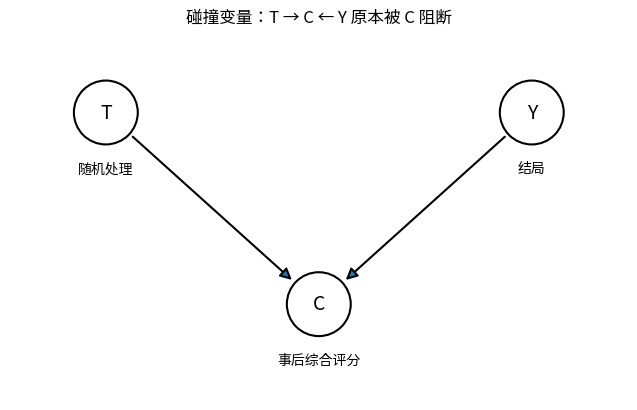

In [12]:
draw_dag(
    positions={"T": (0, 1.8), "Y": (4, 1.8), "C": (2, 0)},
    edges=[("T", "C"), ("Y", "C")],
    labels={"T": "随机处理", "Y": "结局", "C": "事后综合评分"},
    title="碰撞变量：T → C ← Y 原本被 C 阻断",
)

In [13]:
def generate_collider(n: int, rng: np.random.Generator):
    """T 不影响 Y，但 T 与 Y 共同影响事后评分 C。"""
    t = rng.binomial(1, 0.5, size=n)
    noise_y = rng.normal(size=n)
    noise_c = rng.normal(size=n)
    y0 = noise_y
    y1 = noise_y.copy()
    y = np.where(t == 1, y1, y0)
    c = t + y + noise_c
    observed = pd.DataFrame({"T": t, "Y": y, "C": c})
    truth = pd.DataFrame({"Y0": y0, "Y1": y1})
    return observed, truth

observed_col, truth_col = generate_collider(
    N_MAIN, np.random.default_rng(SEED_COLLIDER)
)
display(observed_col.head().round(3))
print(f"模拟真实总效应：{(truth_col['Y1'] - truth_col['Y0']).mean():.4f}")

,T,Y,C
0,0,-1.440,-0.286
1,0,-0.175,-0.319
2,0,0.313,0.694
3,1,0.028,0.108
4,0,0.337,-1.216


模拟真实总效应：0.0000


### 2. 同一份数据，做两次回归

`Y ~ T` 不调整 $C$。`Y ~ T + C` 则在比较综合评分相同的人：如果其中一个人的评分已经因 $T=1$ 多了一部分，$Y$ 与评分噪声就需要共同补偿这个差别。这种比较会引入原本没有的关联。

In [14]:
coef_col_raw = fit_ols(observed_col["Y"], observed_col["T"])
coef_col_adjusted = fit_ols(observed_col["Y"], observed_col["T"], observed_col["C"])
display(pd.DataFrame({
    "模型": ["Y ~ T", "Y ~ T + C"],
    "T 的回归系数": [coef_col_raw[1], coef_col_adjusted[1]],
    "本模型的总体回归系数": [0.0, -0.5],
    "真实总效应": [0.0, 0.0],
}).round(4))

,模型,T 的回归系数,本模型的总体回归系数,真实总效应
0,Y ~ T,0.0216,0.0,0.0
1,Y ~ T + C,-0.4951,-0.5,0.0


默认输出中，不调整时系数约为 0.0216，调整 $C$ 后约为 -0.4951。为什么后者接近 $-0.5$？给定 $T,C$ 后，已知：

$$
C-T=\varepsilon_Y+\varepsilon_C.
$$

右边是两个独立、同方差的正态变量。它们在给定和以后，条件均值各占一半，因此：

$$
E[Y\mid T,C]=\frac{C-T}{2}=\frac12 C-\frac12 T.
$$

这个 $-0.5$ 是条件均值里的回归系数，而真正的干预效应始终是 $E[Y(1)-Y(0)]=0$。这与 [2] 第 6.3 节的推理相同；把原因变量之一改成二元 $T$ 后，上面给定 $T$ 的计算仍然成立。

### 3. 把条件比较画出来

将 $C$ 分成五个等频区间，分别计算两组的 $C$、$Y$ 均值。分箱只是为了看图：同一个箱内的 $C$ 并不完全相同，不能把分箱差异当作精确条件化的结果，也不是对无混杂假设的检验。

C均值    Y均值   人数
C区间 T                   
0   0 -1.651 -0.833  890
    1 -1.486 -1.219  310
1   0 -0.301 -0.174  731
    1 -0.288 -0.626  469
2   0  0.496  0.239  583
    1  0.530 -0.237  617
3   0  1.315  0.626  462
    1  1.346  0.142  738
4   0  2.457  1.264  305
    1  2.665  0.808  895

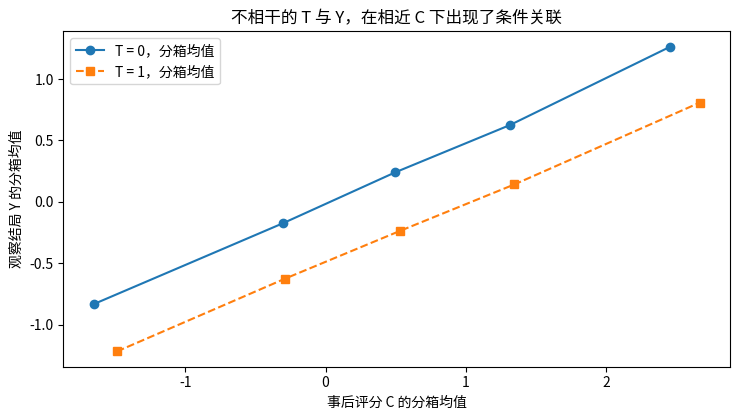

In [15]:
col_for_plot = observed_col.assign(
    C区间=pd.qcut(observed_col["C"], q=5, labels=False)
)
conditional_means = col_for_plot.groupby(["C区间", "T"]).agg(
    C均值=("C", "mean"), Y均值=("Y", "mean"), 人数=("Y", "size")
)
display(conditional_means.round(3))

fig, ax = plt.subplots(figsize=(7.5, 4.3))
for t, marker, style in [(0, "o", "-"), (1, "s", "--")]:
    part = conditional_means.xs(t, level="T")
    ax.plot(part["C均值"], part["Y均值"], marker=marker, linestyle=style,
            label=f"T = {t}，分箱均值")
ax.set_xlabel("事后评分 C 的分箱均值")
ax.set_ylabel("观察结局 Y 的分箱均值")
ax.set_title("不相干的 T 与 Y，在相近 C 下出现了条件关联")
ax.legend()
fig.tight_layout()
plt.show()
plt.close(fig)

不按 $C$ 分层时，两组的 $Y$ 均值接近；在相近的 $C$ 处，$T=1$ 组的 $Y$ 却偏低。并不是处理突然产生了负效应，而是筛选和比较的规则变了。

即使回归里不写 $C$，只保留 $0\leq C\leq1$ 的记录，再比较两组，也会条件化在一个碰撞变量的范围上。下面在同一份观察数据上做这个筛选。

In [16]:
selected_col = observed_col.loc[observed_col["C"].between(0, 1)].copy()
selected_coef = fit_ols(selected_col["Y"], selected_col["T"])[1]
display(pd.DataFrame({
    "使用的记录": ["全部记录", "仅保留 0 ≤ C ≤ 1"],
    "人数": [len(observed_col), len(selected_col)],
    "不调整 C 的组间均值差": [coef_col_raw[1], selected_coef],
}))

,使用的记录,人数,不调整 C 的组间均值差
0,全部记录,6000,0.021583
1,仅保留 0 ≤ C ≤ 1,1570,-0.443501


默认筛选留下了 1,570 人，观察差值约为 -0.4435。限制一个区间不等于固定一个精确值，所以它不要求恰好是 $-0.5$。但这个实验说明：选择偏差不只来自回归公式，也可能来自数据收集或纳入标准。[2，第 6.3、11.3 节]

这里没有把 $T\to C\leftarrow Y$ 叫作后门路径，因为它从 $T$ 出发时的第一条箭头不是指向 $T$。问题在于我们条件化了处理和结局的共同后果；经典后门准则本来就不允许把处理的后代 $C$ 放进这样的调整集合。

## 进一步分析

### 1. 换很多份数据，再检查一次

前三个例子各只生成了一份数据，回归系数还带有抽样波动。下面每次重新生成 600 个人的数据，每个结构重复 1,000 次。两种回归总在同一份数据上比较，真值单独从模拟完整表读取。

注意：这里每次重新抽取人和误差，不是第二篇固定潜在结局后仅改变处理标签。本节始终以总效应为目标；中介模型调整后的系数若用于直接效应有另一种解释，但不能拿来回答总效应问题。

In [17]:
case_settings = {
    "混杂": (generate_confounding, "X"),
    "中介": (generate_mediation, "M"),
    "碰撞": (generate_collider, "C"),
}
records = []
for case_index, (case_name, (generator, control)) in enumerate(case_settings.items()):
    rng = np.random.default_rng(SEED_REPEAT + case_index)
    for repeat in range(N_REPEATS):
        obs, truth = generator(N_REPEAT_SAMPLE, rng)
        y = obs["Y"].to_numpy()
        t = obs["T"].to_numpy()
        v = obs[control].to_numpy()
        true_total = float((truth["Y1"] - truth["Y0"]).mean())
        for strategy, estimate in [
            ("不调整", fit_ols(y, t)[1]),
            (f"调整 {control}", fit_ols(y, t, v)[1]),
        ]:
            records.append({
                "结构": case_name, "做法": strategy, "重复": repeat,
                "估计值": float(estimate), "真实总效应": true_total,
            })

repeat_results = pd.DataFrame(records)
repeat_results["相对总效应的误差"] = repeat_results["估计值"] - repeat_results["真实总效应"]
summary_rows = []
for (case_name, strategy), part in repeat_results.groupby(["结构", "做法"], sort=False):
    error = part["相对总效应的误差"].to_numpy()
    summary_rows.append({
        "结构": case_name, "做法": strategy,
        "平均估计": part["估计值"].mean(),
        "真实总效应": part["真实总效应"].mean(),
        "模拟偏差": error.mean(),
        "单次估计标准差": part["估计值"].std(ddof=1),
        "偏差的MC标准误": error.std(ddof=1) / np.sqrt(len(error)),
        "RMSE": np.sqrt(np.mean(error ** 2)),
    })
repeat_summary = pd.DataFrame(summary_rows)
display(repeat_summary.round(4))

,结构,做法,平均估计,真实总效应,模拟偏差,单次估计标准差,偏差的MC标准误,RMSE
0,混杂,不调整,3.8008,2.0,1.8008,0.1267,0.0040,1.8052
1,混杂,调整 X,2.0020,2.0,0.0020,0.1035,0.0033,0.1035
2,中介,不调整,3.9958,4.0,-0.0042,0.1821,0.0058,0.1821
3,中介,调整 M,0.9948,4.0,-3.0052,0.1030,0.0033,3.0070
4,碰撞,不调整,-0.0034,0.0,-0.0034,0.0785,0.0025,0.0785
5,碰撞,调整 C,-0.5013,0.0,-0.5013,0.0622,0.0020,0.5052


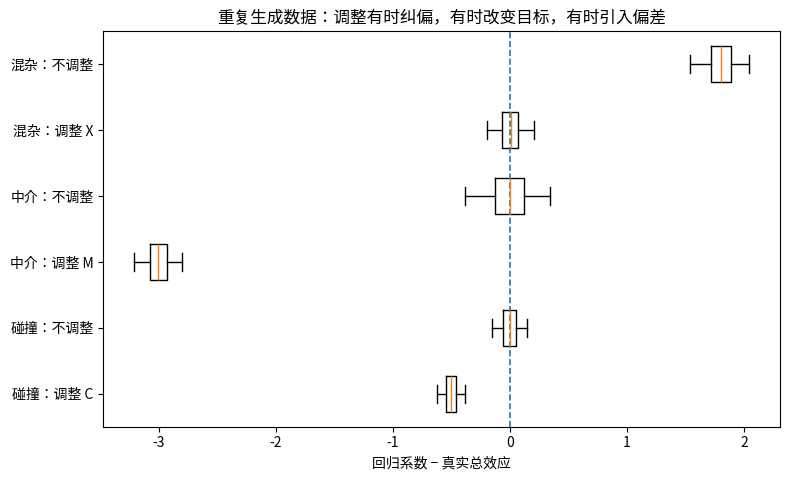

In [18]:
error_arrays, error_labels = [], []
for _, row in repeat_summary.iterrows():
    mask = ((repeat_results["结构"] == row["结构"])
            & (repeat_results["做法"] == row["做法"]))
    error_arrays.append(repeat_results.loc[mask, "相对总效应的误差"].to_numpy())
    error_labels.append(f"{row['结构']}：{row['做法']}")

fig, ax = plt.subplots(figsize=(8.0, 4.9))
ax.boxplot(error_arrays, vert=False, widths=0.55, whis=(2.5, 97.5), showfliers=False)
ax.set_yticks(np.arange(1, len(error_labels) + 1), error_labels)
ax.axvline(0, linestyle="--", linewidth=1.2)
ax.invert_yaxis()
ax.set_xlabel("回归系数 − 真实总效应")
ax.set_title("重复生成数据：调整有时纠偏，有时改变目标，有时引入偏差")
fig.tight_layout()
plt.show()
plt.close(fig)

混杂模型中，不调整的误差集中在 1.8 附近，调整 $X$ 后回到 0 附近。中介模型中，不调整可以估计总效应，调整 $M$ 后与总效应相差约 -3。碰撞模型中，本来接近 0 的误差在调整 $C$ 后变成约 -0.5。

图中箱体表示各次估计误差的中间 50%，两端须线取 2.5% 和 97.5% 分位数；它们是重复模拟的分布摘要，不是某一次研究的 95% 置信区间。为避免图面拥挤，分位数以外的点未单独显示，但表格统计使用全部重复结果。

表中的 MC 标准误衡量“这 1,000 次估计平均以后”的数值波动。增加重复次数能把模拟平均算得更稳定，却不能纠正错误的调整集合。

### 2. 图上选对变量，还需要重叠

回到第一个共同原因结构，改成 $T=X$：基础类别 1 全部接受处理，类别 0 全部进入对照。此时 $e(0)=0$、$e(1)=1$，没有层内的两种处理对照。

下面构造两个世界。它们共享同一份 $X$ 和同一个误差，但处理效应不同：

$$
\begin{aligned}
\text{世界 A：}\quad &Y_A(t)=10+3X+\varepsilon,\\
\text{世界 B：}\quad &Y_B(t)=10+2t+X+\varepsilon.
\end{aligned}
$$

A 的 ATE 为 0，B 的 ATE 为 2。但只要实际 $T=X$，两者的观察结局都等于 $10+3X+\varepsilon$。这是根据 [2] 第 5.2 节重叠要求另外构造的例子，不是书中的数据。

给定 $X$ 后，$T$ 已经是常数，条件可忽略性在这个设定中并不能排除任一世界；缺少的恰恰是处理状态的重叠。

In [19]:
rng_overlap = np.random.default_rng(SEED_OVERLAP)
x_overlap = rng_overlap.binomial(1, 0.5, size=1000)
t_overlap = x_overlap.copy()
noise_overlap = rng_overlap.normal(size=x_overlap.size)

y0_a = 10 + 3 * x_overlap + noise_overlap
y1_a = y0_a.copy()
y0_b = 10 + x_overlap + noise_overlap
y1_b = y0_b + 2
obs_a = np.where(t_overlap == 1, y1_a, y0_a)
obs_b = np.where(t_overlap == 1, y1_b, y0_b)
np.testing.assert_allclose(obs_a, obs_b)

counts_overlap = pd.crosstab(
    pd.Series(x_overlap, name="X"), pd.Series(t_overlap, name="T")
).reindex(index=[0, 1], columns=[0, 1], fill_value=0)
display(counts_overlap)
display(pd.DataFrame({
    "世界": ["A", "B"],
    "真实ATE": [(y1_a - y0_a).mean(), (y1_b - y0_b).mean()],
    "观察结局均值": [obs_a.mean(), obs_b.mean()],
}))

design_overlap = np.column_stack([np.ones(x_overlap.size), t_overlap, x_overlap])
print(f"设计矩阵有 {design_overlap.shape[1]} 列，秩为 {np.linalg.matrix_rank(design_overlap)}。")
# 演示前面函数对不可分辨系数的处理；这是预期情况，不让它中断整篇运行。
try:
    fit_ols(obs_a, t_overlap, x_overlap)
except ValueError as exc:
    print(f"停止拟合：{exc}")

T,0,1
X,,
0,499,0
1,0,501


,世界,真实ATE,观察结局均值
0,A,0.0,11.469397
1,B,2.0,11.469397


设计矩阵有 3 列，秩为 2。
停止拟合：设计矩阵不满秩：不能单独确定每个回归系数。


表格中的 0 表示没有观察到该处理—协变量组合，不是该组合下的平均结局为 0。

`T` 与 `X` 两列完全相同，数据不能分辨“处理作用 0、基础作用 3”和“处理作用 2、基础作用 1”。这不只是一个需要换优化器的数值问题：不增加额外结构或可比较的数据，目标效应就不能用本篇的调整策略识别。

重叠不足与重叠完全消失也要区分。某种处理在一类人中很少见，主要会让比较不稳定；本例则让该类人的另一种处理概率严格为零，连无限增加同机制的样本也不会出现缺失的组合。[2，第 5.2 节]

## 结果分析

三个例子使用同一个回归函数，差别不是算法性能，而是变量在因果结构中的位置。

| 本篇结构 | 目标都是总效应时，增加的变量做了什么？ | 默认模型中的结果 |
|---|---|---|
| 共同原因 $X$ | 阻断后门路径 | 从约 3.8 调整到真实效应 2 |
| 中介 $M$ | 阻断一部分真实作用路径 | 从总效应 4 变为本例的直接效应 1 |
| 碰撞变量 $C$ | 打开原本被阻断的非因果路径 | 从约 0 变为约 -0.5，真实效应仍为 0 |

这张表只总结本篇明确给定的结构，不能脱离完整 DAG 套用。实际研究中，一个变量可能出现在多条路径上；删掉它可能打开一条路径，加入它也可能打开另一条路径。

分析前至少应说清楚：处理和结局是什么、目标是总效应还是直接效应、变量在哪个时间点确定、样本经历了什么筛选。然后才讨论调整集合，以及是否有足够重叠来实施比较。[1，第 16 章；2，第 11 章]

## 练习

### 1. 不调整碰撞变量，只调整它的后代呢？

在第三个案例中，再记录一个带误差的评分 $R=C+\varepsilon_R$，其中 $\varepsilon_R\sim N(0,1)$，与所有已有变量独立。图中只新增 $C\to R$；$R$ 本身不会影响 $Y$。

比较 `Y ~ T`、`Y ~ T + C` 和 `Y ~ T + R`。后者是否就能避开碰撞偏差？先按路径规则判断，再运行下面的代码。[2，第 7.3 节，碰撞变量后代的条件化]

In [20]:
rng_desc = np.random.default_rng(SEED_DESCENDANT)
observed_desc = observed_col.assign(
    R=observed_col["C"].to_numpy() + rng_desc.normal(size=len(observed_col))
)
coef_desc = fit_ols(observed_desc["Y"], observed_desc["T"], observed_desc["R"])
display(pd.DataFrame({
    "模型": ["Y ~ T", "Y ~ T + C", "Y ~ T + R"],
    "T 的回归系数": [coef_col_raw[1], coef_col_adjusted[1], coef_desc[1]],
    "本模型的总体回归系数": [0.0, -0.5, -1 / 3],
    "真实总效应": [0.0, 0.0, 0.0],
}).round(4))

,模型,T 的回归系数,本模型的总体回归系数,真实总效应
0,Y ~ T,0.0216,0.0000,0.0
1,Y ~ T + C,-0.4951,-0.5000,0.0
2,Y ~ T + R,-0.3307,-0.3333,0.0


调整 $R$ 仍会打开 $T\to C\leftarrow Y$ 的碰撞点；不必在公式中直接出现 $C$。

具体数值也能检查。因为 $R-T=\varepsilon_Y+\varepsilon_C+\varepsilon_R$，三个独立标准正态变量在给定和以后，条件均值各占三分之一，所以：

$$
E[Y\mid T,R]=\frac{R-T}{3}.
$$

因此调整后系数接近 $-1/3$。偏差比调整 $C$ 时小，是本例新增测量噪声后的结果，不代表“代理变量总能减轻偏差”。只要原路径没有其他阻断点，条件化碰撞变量的后代就仍有打开路径的风险。

### 2. 只用处理前变量，就一定安全吗？

考虑 Ding 第 16.3.1 节的 M 结构。两个独立的未观测因素 $U_1,U_2$ 分别影响处理和结局，共同决定一个处理前变量 $X$：

$$
T\leftarrow U_1\to X\leftarrow U_2\to Y.
$$

虽然 $X$ 在处理前确定，它仍然是这条路径上的碰撞变量。本题沿用原书的线性正态模型形式，将四个路径系数都设为 1：

$$
X=U_1+U_2+\varepsilon_X,\qquad
T=U_1+\varepsilon_T,\qquad
Y(t)=U_2+\varepsilon_Y.
$$

五个外生变量相互独立，均为标准正态。这里的 $T$ 改为连续暴露，与前三个案例的二元处理不同；目标是令 $T$ 从 0 增加到 1 的效应，仍然为 0。前面的二元处理概率公式不直接用于这一题。原书也说明连续暴露是为了简化这个反例的推导。[1，第 16.3.1 节及脚注]

只读取可观察的 $T,X,Y$，比较不调整和调整 $X$ 的回归系数。

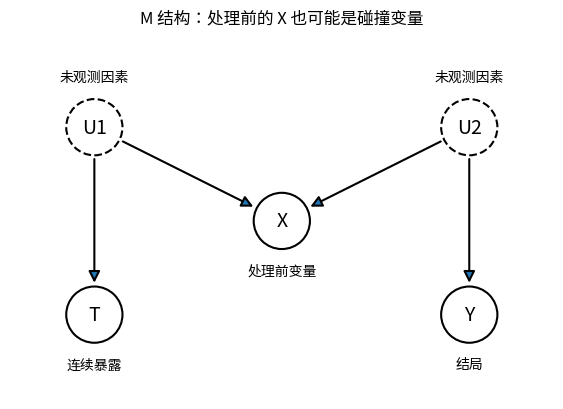

In [21]:
draw_dag(
    positions={"U1": (0, 2), "U2": (4, 2), "X": (2, 1), "T": (0, 0), "Y": (4, 0)},
    edges=[("U1", "X"), ("U2", "X"), ("U1", "T"), ("U2", "Y")],
    labels={"U1": "未观测因素", "U2": "未观测因素", "X": "处理前变量", "T": "连续暴露", "Y": "结局"},
    title="M 结构：处理前的 X 也可能是碰撞变量", latent=("U1", "U2"),
)

In [22]:
rng_m_bias = np.random.default_rng(SEED_M_BIAS)
u1, u2, noise_x, noise_t, noise_y = rng_m_bias.normal(size=(5, 60000))
observed_m_bias = pd.DataFrame({
    "T": u1 + noise_t,
    "X": u1 + u2 + noise_x,
    "Y": u2 + noise_y,
})
b_m_raw = fit_ols(observed_m_bias["Y"], observed_m_bias["T"])[1]
b_m_adjusted = fit_ols(observed_m_bias["Y"], observed_m_bias["T"], observed_m_bias["X"])[1]
display(pd.DataFrame({
    "模型": ["Y ~ T", "Y ~ T + X"],
    "T 的回归系数": [b_m_raw, b_m_adjusted],
    "本模型的总体回归系数": [0.0, -0.2],
    "真实单位暴露效应": [0.0, 0.0],
}).round(4))

,模型,T 的回归系数,本模型的总体回归系数,真实单位暴露效应
0,Y ~ T,0.0046,0.0,0.0
1,Y ~ T + X,-0.1977,-0.2,0.0


不调整的系数接近 0，调整后接近 $-0.2$。这个理论值也能由两自变量回归的总体公式算出。本例 $\operatorname{Var}(T)=2$、$\operatorname{Var}(X)=3$、$\operatorname{Cov}(T,X)=\operatorname{Cov}(Y,X)=1$，而 $\operatorname{Cov}(T,Y)=0$，因此：

$$
\beta_{T\mid X}
=\frac{\operatorname{Cov}(T,Y)\operatorname{Var}(X)
-\operatorname{Cov}(T,X)\operatorname{Cov}(X,Y)}
{\operatorname{Var}(T)\operatorname{Var}(X)-\operatorname{Cov}(T,X)^2}
=\frac{0\times3-1\times1}{2\times3-1}=-\frac15.
$$

这是按本题系数对原书模型作的代数核对。[1，附录 B.1及第 16.3.1 节]

这个反例否定的是“处理前的变量全部调整总不会错”，不是要求把所有基线变量都删掉。它依赖 $U_1,U_2$ 独立且 $X$ 不直接影响 $T,Y$ 等明确设定；改变这些箭头和独立关系，不调整也可能有混杂。[2，第 11.3 节对 M 结构的后续讨论]

## 总结

因果图帮助我们把“为什么调整”说清楚。对于总效应，共同原因、中介和碰撞变量的作用不同；同一个回归公式，在不同结构下可以是在纠偏，也可以是在改变问题或引入偏差。

从图得到调整方案以后，还要说明处理的一致性、无干扰、条件可忽略性与重叠。满足这些条件，才有依据把潜在结局的平均差写成观察数据的调整公式。至于图本身是否可信，并不能由一次拟合成功或一个显著系数来保证。

下一篇使用这里的调整公式，进一步讨论回归调整与标准化：怎样为同一目标人群计算两种处理下的平均结局，以及模型形式不合适时会发生什么。

## 参考资料

[1] Peng Ding. *A First Course in Causal Inference*. arXiv:2305.18793v2，2023-10-03。对应上传文件 `因果推断.pdf`。主要使用第 10.3–10.4 节（正文第 142–148 页，识别、可忽略性与标准化）、第 16.1–16.3.1 节（第 219–225 页，因果图、无混杂假设与 M-bias）；另参考第 2.2 节（第 16–18 页，SUTVA）及附录 B.1–B.2（第 421–423 页，最小二乘）。例如正文第 219 页对应上传 PDF 第 245 页。

[2] Victor Chernozhukov, Christian Hansen, Nathan Kallus, Martin Spindler, Vasilis Syrgkanis. *Applied Causal Inference Powered by ML and AI*. Version 0.1.2，2026-05-03。对应上传文件 `CausalML_book_2022.pdf`，以扉页版本为准。主要使用第 5.2 节（正文第 134–139 页，条件可忽略性与重叠）、第 6.2–6.3 节（第 156–161 页，线性路径与碰撞偏差）、第 7.2–7.4 节（第 174–190 页，结构方程、反事实、d-分离与后门准则），以及第 11.3 节（第 313–321 页，合适与不合适的控制变量）。正文第 183 页对应上传 PDF 第 193 页。

本篇不是对上述章节的逐节翻译。共同原因与中介模型的参数、二元处理的碰撞模型、无重叠的两个世界及碰撞变量后代练习，均是依据书中结构另设的教学构造；M-bias 练习保留 [1] 的模型形式，改设系数与样本量。相应理论量由本篇设定直接推导，不能作为真实研究结论。图表全部来自当前代码，不是书中截图。